In [19]:
import pandas as pd
import matplotlib.pyplot as plt

# 解决负号显示问题
plt.rcParams["axes.unicode_minus"] = False

In [20]:
df = pd.read_excel("data/Online Retail.xlsx")

In [21]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [26]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


In [25]:
df.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID
count,541909.000000,541909,541909.000000,406829.000000
mean,9.552250,2011-07-04 13:34:57.156386048,4.611114,15287.690570
min,-80995.000000,2010-12-01 08:26:00,-11062.060000,12346.000000
25%,1.000000,2011-03-28 11:34:00,1.250000,13953.000000
50%,3.000000,2011-07-19 17:17:00,2.080000,15152.000000
75%,10.000000,2011-10-19 11:27:00,4.130000,16791.000000
max,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000
std,218.081158,NaN,96.759853,1713.600303


In [27]:
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [28]:
df_clean = df.copy()

In [29]:
df_clean = df_clean.dropna(subset=["CustomerID"])

In [30]:
df_clean = df_clean.dropna(subset=["Description"])

In [31]:
df_clean = df_clean[df_clean["Quantity"] > 0]
df_clean = df_clean[df_clean["UnitPrice"] > 0]

In [32]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 397884 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    397884 non-null  object        
 1   StockCode    397884 non-null  object        
 2   Description  397884 non-null  object        
 3   Quantity     397884 non-null  int64         
 4   InvoiceDate  397884 non-null  datetime64[ns]
 5   UnitPrice    397884 non-null  float64       
 6   CustomerID   397884 non-null  float64       
 7   Country      397884 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 27.3+ MB


In [33]:
df_clean["Sales"] = df_clean["Quantity"] * df_clean["UnitPrice"]

In [34]:
top_products = df_clean.groupby("Description")["Sales"].sum().sort_values(ascending=False).head(10)
top_products

Description
PAPER CRAFT , LITTLE BIRDIE           168469.60
REGENCY CAKESTAND 3 TIER              142592.95
WHITE HANGING HEART T-LIGHT HOLDER    100448.15
JUMBO BAG RED RETROSPOT                85220.78
MEDIUM CERAMIC TOP STORAGE JAR         81416.73
POSTAGE                                77803.96
PARTY BUNTING                          68844.33
ASSORTED COLOUR BIRD ORNAMENT          56580.34
Manual                                 53779.93
RABBIT NIGHT LIGHT                     51346.20
Name: Sales, dtype: float64

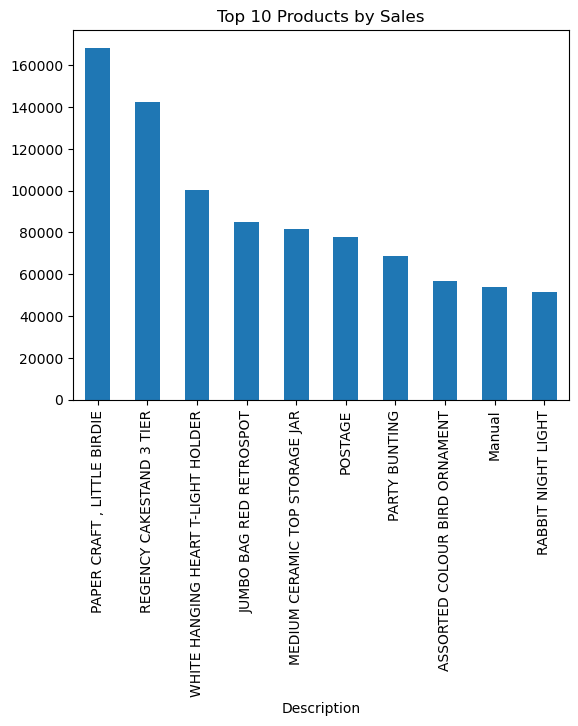

In [35]:
import matplotlib.pyplot as plt

top_products.plot(kind="bar")
plt.title("Top 10 Products by Sales")
plt.show()

In [36]:
df_clean.groupby("Country")["Sales"].sum().sort_values(ascending=False).head(10)

Country
United Kingdom    7308391.554
Netherlands        285446.340
EIRE               265545.900
Germany            228867.140
France             209024.050
Australia          138521.310
Spain               61577.110
Switzerland         56443.950
Belgium             41196.340
Sweden              38378.330
Name: Sales, dtype: float64

In [37]:
df_clean["Month"] = df_clean["InvoiceDate"].dt.to_period("M")
monthly_sales = df_clean.groupby("Month")["Sales"].sum()
monthly_sales

Month
2010-12     572713.890
2011-01     569445.040
2011-02     447137.350
2011-03     595500.760
2011-04     469200.361
2011-05     678594.560
2011-06     661213.690
2011-07     600091.011
2011-08     645343.900
2011-09     952838.382
2011-10    1039318.790
2011-11    1161817.380
2011-12     518192.790
Freq: M, Name: Sales, dtype: float64

<Axes: xlabel='Month'>

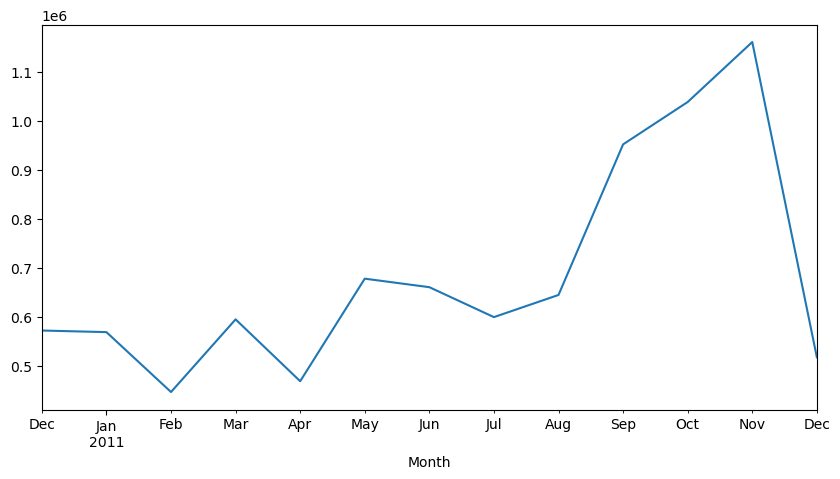

In [38]:
monthly_sales.plot(kind="line", figsize=(10,5))

In [39]:
df['Month'] = df['InvoiceDate'].dt.to_period('M')

df.groupby('Month')['InvoiceNo'].nunique()

Month
2010-12    2025
2011-01    1476
2011-02    1393
2011-03    1983
2011-04    1744
2011-05    2162
2011-06    2012
2011-07    1927
2011-08    1737
2011-09    2327
2011-10    2637
2011-11    3462
2011-12    1015
Freq: M, Name: InvoiceNo, dtype: int64

In [40]:
df.groupby('Month')['Quantity'].sum()

Month
2010-12    342228
2011-01    308966
2011-02    277989
2011-03    351872
2011-04    289098
2011-05    380391
2011-06    341623
2011-07    391116
2011-08    406199
2011-09    549817
2011-10    570532
2011-11    740286
2011-12    226333
Freq: M, Name: Quantity, dtype: int64

In [41]:
df.groupby('Month')['UnitPrice'].mean()

Month
2010-12    6.132644
2011-01    4.915151
2011-02    4.599876
2011-03    4.666554
2011-04    4.317588
2011-05    5.149486
2011-06    5.443330
2011-07    4.350088
2011-08    4.262149
2011-09    3.966774
2011-10    4.336935
2011-11    3.861952
2011-12    5.246451
Freq: M, Name: UnitPrice, dtype: float64

In [43]:
df['Sales'] = df['Quantity'] * df['UnitPrice']

monthly = df.groupby('Month').agg({
    'Sales': 'sum',
    'InvoiceNo': 'nunique',
    'CustomerID': 'nunique'
})

monthly['AOV'] = monthly['Sales'] / monthly['InvoiceNo']
monthly

,Sales,InvoiceNo,CustomerID,AOV
Month,,,,
2010-12,748957.020,2025,948,369.855319
2011-01,560000.260,1476,783,379.403970
2011-02,498062.650,1393,798,357.546770
2011-03,683267.080,1983,1020,344.562320
2011-04,493207.121,1744,899,282.802248
2011-05,723333.510,2162,1079,334.566841
2011-06,691123.120,2012,1051,343.500557
2011-07,681300.111,1927,993,353.554806
2011-08,682680.510,1737,980,393.022746


In [44]:
import pandas as pd

df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

snapshot_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)
snapshot_date

Timestamp('2011-12-10 12:50:00')

In [45]:
rfm = df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days,  # R
    'InvoiceNo': 'nunique',                                   # F
    'Sales': 'sum'                                            # M
})

rfm.columns = ['Recency', 'Frequency', 'Monetary']
rfm.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346.0,326,2,0.00
12347.0,2,7,4310.00
12348.0,75,4,1797.24
12349.0,19,1,1757.55
12350.0,310,1,334.40


In [49]:
rfm['R_score'] = pd.qcut(rfm['Recency'], 4, labels=[4,3,2,1])

rfm['F_score'] = pd.qcut(
    rfm['Frequency'].rank(method='first'),
    4,
    labels=[1,2,3,4]
)

rfm['M_score'] = pd.qcut(
    rfm['Monetary'].rank(method='first'),
    4,
    labels=[1,2,3,4]
)

In [50]:
rfm['RFM_score'] = (
    rfm['R_score'].astype(str) +
    rfm['F_score'].astype(str) +
    rfm['M_score'].astype(str)
)

rfm.head()

,Recency,Frequency,Monetary,R_score,F_score,M_score,RFM_score
CustomerID,,,,,,,
12346.0,326,2,0.00,1,2,1,121
12347.0,2,7,4310.00,4,4,4,444
12348.0,75,4,1797.24,2,3,4,234
12349.0,19,1,1757.55,3,1,4,314
12350.0,310,1,334.40,1,1,2,112


In [51]:
def segment(row):
    if row['R_score'] == 4 and row['F_score'] == 4 and row['M_score'] == 4:
        return 'Champions（高价值客户）'
    
    elif row['R_score'] >= 3 and row['F_score'] >= 3:
        return 'Loyal（忠诚客户）'
    
    elif row['R_score'] == 4 and row['F_score'] <= 2:
        return 'New Customers（新客户）'
    
    elif row['R_score'] <= 2:
        return 'At Risk（流失风险）'
    
    else:
        return 'Others'

rfm['Segment'] = rfm.apply(segment, axis=1)

rfm['Segment'].value_counts()

Segment
At Risk（流失风险）         2167
Loyal（忠诚客户）           1034
Champions（高价值客户）       498
Others                 435
New Customers（新客户）     238
Name: count, dtype: int64

In [52]:
rfm['Segment'].value_counts()

Segment
At Risk（流失风险）         2167
Loyal（忠诚客户）           1034
Champions（高价值客户）       498
Others                 435
New Customers（新客户）     238
Name: count, dtype: int64

<Axes: xlabel='Segment'>

/opt/anaconda3/lib/python3.13/site-packages/IPython/core/events.py:82: UserWarning: Glyph 65288 (\N{FULLWIDTH LEFT PARENTHESIS}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/opt/anaconda3/lib/python3.13/site-packages/IPython/core/events.py:82: UserWarning: Glyph 27969 (\N{CJK UNIFIED IDEOGRAPH-6D41}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/opt/anaconda3/lib/python3.13/site-packages/IPython/core/events.py:82: UserWarning: Glyph 22833 (\N{CJK UNIFIED IDEOGRAPH-5931}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/opt/anaconda3/lib/python3.13/site-packages/IPython/core/events.py:82: UserWarning: Glyph 39118 (\N{CJK UNIFIED IDEOGRAPH-98CE}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/opt/anaconda3/lib/python3.13/site-packages/IPython/core/events.py:82: UserWarning: Glyph 38505 (\N{CJK UNIFIED IDEOGRAPH-9669}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/opt/anaconda3/lib/python3.13/site-packages/IPython/core/events.p

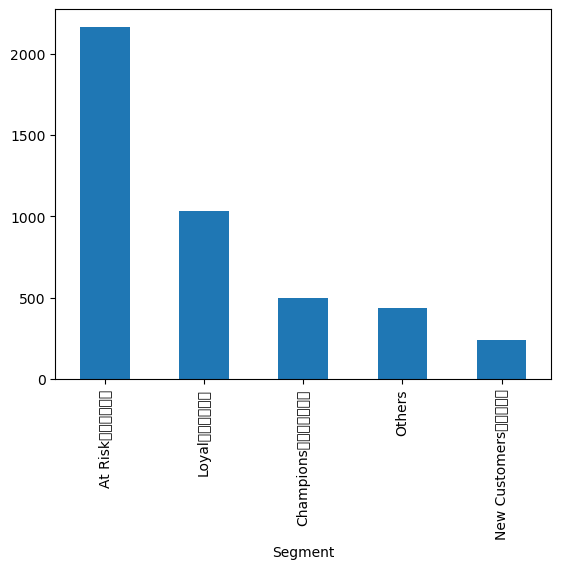

In [53]:
rfm['Segment'].value_counts().plot(kind='bar')

In [54]:
rfm.groupby('Segment')['Monetary'].sum().sort_values(ascending=False)

Segment
Champions（高价值客户）      4372514.140
Loyal（忠诚客户）           2033177.851
At Risk（流失风险）         1571116.113
Others                 199482.080
New Customers（新客户）     123775.630
Name: Monetary, dtype: float64

In [55]:
rfm.groupby('Segment').agg({
    'Monetary': 'mean',
    'Frequency': 'mean',
    'Recency': 'mean'
})

,Monetary,Frequency,Recency
Segment,,,
At Risk（流失风险）,725.018972,2.474850,166.293032
Champions（高价值客户）,8780.148876,18.819277,6.847390
Loyal（忠诚客户）,1966.322873,6.190522,21.868472
New Customers（新客户）,520.065672,1.684874,8.932773
Others,458.579494,1.501149,32.011494


In [56]:
segment_sales = rfm.groupby('Segment')['Monetary'].sum()
segment_sales / segment_sales.sum()

Segment
At Risk（流失风险）         0.189290
Champions（高价值客户）      0.526805
Loyal（忠诚客户）           0.244959
New Customers（新客户）    0.014913
Others                0.024034
Name: Monetary, dtype: float64

<Axes: xlabel='Segment'>

/opt/anaconda3/lib/python3.13/site-packages/IPython/core/events.py:82: UserWarning: Glyph 65288 (\N{FULLWIDTH LEFT PARENTHESIS}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/opt/anaconda3/lib/python3.13/site-packages/IPython/core/events.py:82: UserWarning: Glyph 27969 (\N{CJK UNIFIED IDEOGRAPH-6D41}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/opt/anaconda3/lib/python3.13/site-packages/IPython/core/events.py:82: UserWarning: Glyph 22833 (\N{CJK UNIFIED IDEOGRAPH-5931}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/opt/anaconda3/lib/python3.13/site-packages/IPython/core/events.py:82: UserWarning: Glyph 39118 (\N{CJK UNIFIED IDEOGRAPH-98CE}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/opt/anaconda3/lib/python3.13/site-packages/IPython/core/events.py:82: UserWarning: Glyph 38505 (\N{CJK UNIFIED IDEOGRAPH-9669}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/opt/anaconda3/lib/python3.13/site-packages/IPython/core/events.p

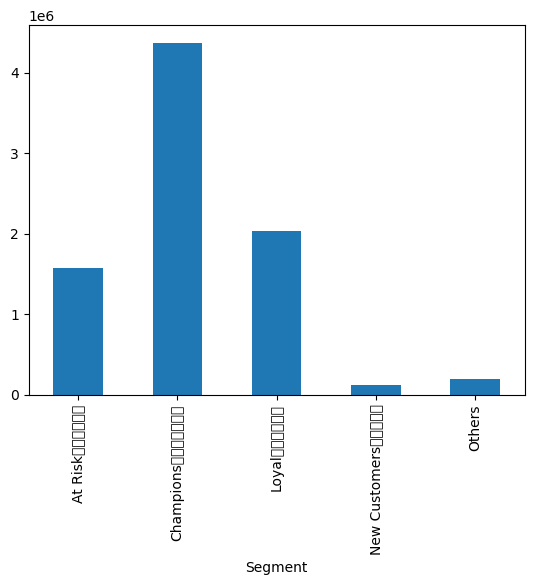

In [57]:
segment_sales.plot(kind='bar')

<Axes: ylabel='Monetary'>

/opt/anaconda3/lib/python3.13/site-packages/IPython/core/events.py:82: UserWarning: Glyph 65288 (\N{FULLWIDTH LEFT PARENTHESIS}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/opt/anaconda3/lib/python3.13/site-packages/IPython/core/events.py:82: UserWarning: Glyph 27969 (\N{CJK UNIFIED IDEOGRAPH-6D41}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/opt/anaconda3/lib/python3.13/site-packages/IPython/core/events.py:82: UserWarning: Glyph 22833 (\N{CJK UNIFIED IDEOGRAPH-5931}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/opt/anaconda3/lib/python3.13/site-packages/IPython/core/events.py:82: UserWarning: Glyph 39118 (\N{CJK UNIFIED IDEOGRAPH-98CE}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/opt/anaconda3/lib/python3.13/site-packages/IPython/core/events.py:82: UserWarning: Glyph 38505 (\N{CJK UNIFIED IDEOGRAPH-9669}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/opt/anaconda3/lib/python3.13/site-packages/IPython/core/events.p

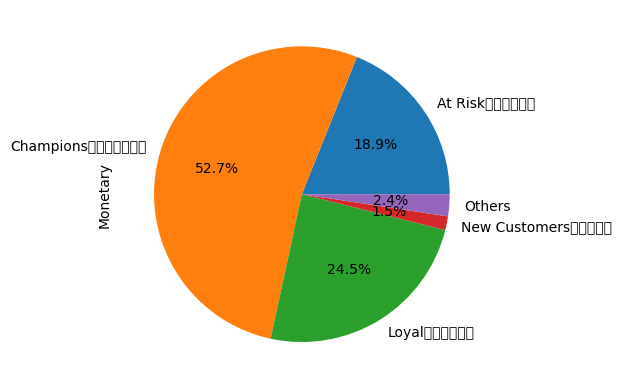

In [58]:
segment_sales.plot.pie(autopct='%1.1f%%')

In [59]:
rfm.groupby('Segment').agg({
    'Monetary': ['sum', 'mean'],
    'Frequency': 'mean',
    'Recency': 'mean'
})

Monetary               Frequency     Recency
                            sum         mean       mean        mean
Segment                                                            
At Risk（流失风险）       1571116.113   725.018972   2.474850  166.293032
Champions（高价值客户）    4372514.140  8780.148876  18.819277    6.847390
Loyal（忠诚客户）         2033177.851  1966.322873   6.190522   21.868472
New Customers（新客户）   123775.630   520.065672   1.684874    8.932773
Others               199482.080   458.579494   1.501149   32.011494